In [1]:
%%html
<style type="text/css">
  span.ecb { background: yellow; }
</style>
<span class="ecb">Grading comments will be in yellow</span>

In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# from IPython.display import display
import itertools

# ATMO 5331 - Homework #3
### Spring 2026, Due 23 Mar, 2026, 11:59 pm.

When working these problems, you will need to code up equations for and make plots of various electrostatic quantities. Turn in a Jupyter notebook with your figures and which I can run to reproduce your results. Label your axes like a professional.

Please also enter your derivations into the notebook using $LaTeX$. Provide any needed discussion as commentary in the notebook in a Markdown cell.

### 1. Comparing numeric and analytic electric field calculations

Combine your HW1 FiPy notebook with the analytic calculation functions for an infinite slab of charge and a point charge. Use the setup from HW1.1, with four charge layers, including the upper negative screening charge.

For each altitude in the FiPy grid, calculate and plot (left panel) the electric field profile from the charged cylinder in FiPy, and (right panel) the difference `({slab, point} - FiPy)` for (top row) the vertical component of the electric field and (bottom row) the total electric field magnitude.

Do this calculation at the center of the stack of charges.

For the point charges, use the same total charge as in each cylinder of charge. For the infinite slab, use the same charge density.

Mark the position of the point charges, and color-shade (with a transparent gray, `alpha=0.2`) the altitude range used for the charge slab.

Discuss the relative errors in the three approaches.

<span class="ecb">(25)</span>.

### Cylinders

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
from fipy import Grid3D, CellVariable, DiffusionTerm
from fipy.tools.numerix import sqrtDot, reshape
import numpy as np

# Set up a 3D grid, using the engineer's coordinate convention
# x coordinate is left/right
# y coordinate is bottom/top
# z coordinate is front/back
Lx = 100.0e3/2
Ly = 100.0e3/2 # meters
Lz = 20.0e3 # approximate height of electrosphere is 65 km, Fig 1.11 MR98
dx = 2.0e3
dy = 2.0e3
dz = 1.0e3

# Horizontal coordinates of the grid center 
Xc, Yc = Lx/2.0, Ly/2.0

# Use image charges?
mirror=False

phiGround = 0. # potential of ground
phiElectrosphere = 300.0e3 # potential of electrosphere, V

print("Value of background electric field is {0} V/m".format((phiElectrosphere-phiGround)/Ly))

mesh = Grid3D(dx=dx, dy=dy, dz=dz, Lx=Lx, Ly=Ly, Lz=Lz )
X, Y, Z = mesh.cellCenters
print(X.shape, Y.shape, Z.shape, type(X))

Value of background electric field is 6.0 V/m
(12500,) (12500,) (12500,) <class 'numpy.ndarray'>


In [5]:
phi = CellVariable(name = "Potential (V)",
                    mesh = mesh,
                    value = phiGround)
rho = CellVariable(name = "Charge density (C m$^{-3}$)", mesh = mesh)

# Set up the Poisson problem
permittivity = 8.854e-12 # vacuum, F/m
phi.equation = (DiffusionTerm(coeff = permittivity) + rho == 0)

# there is also grad, which is first order. facegrad is second order.
# Efield = -phi.faceGrad
# Finally, we can use leastSquaresGrad, which is calculated at the cell centers.
# This is a bit harder to imagine from the point of view of a discretized gradient calculation
# but has the advantage that we can slice the arrays the same way as the scalar variables.
Efield = -phi.leastSquaresGrad
Efield.name = 'Electric Field (V/m)'

# Only need these for faceGrad.
EfaceX, EfaceY, EfaceZ = Efield.mesh.faceCenters
print(EfaceX.shape)

(39125,)


In [6]:
# Zero E field (gradient of potential) on exterior
phi.faceGrad.constrain(0 * mesh.faceNormals, where=mesh.exteriorFaces)

# Zero potential at ground, overwrites previous condition on bottom boundary
phi.constrain(phiGround, mesh.facesFront)

# Potential provided by ionosphere, approximated as a single upper boundary, i.e., the electrosphere
phi.constrain(phiElectrosphere, mesh.facesBack)
    
print(X.shape, mesh.shape, phi.shape)


(12500,) (25, 25, 20) (12500,)


In [7]:
def cylinder_at(rho, rho0, X0, Y0, Z0, depth, radius):
    """ X0, Y0, Z0: Center of cylinder
    rho: whole-domain charge density variable
    rho: charge density to assign at cylinder
    depth: thickness in Z, i.e., Z0-depth/2, Z0+depth/2
    radius: cylinder radius
    """
    
    X, Y, Z = rho.mesh.cellCenters
    
    dX = X-X0
    dY = Y-Y0
    dZ = Z-Z0
    
    charged = (
        (np.sqrt(dX*dX + dY*dY) <= radius) &
        (np.abs(dZ) <= (depth/2.0))
    )
    print("Charging {0} grid boxes".format(charged.sum()))
    
    # Note the warning at https://www.ctcms.nist.gov/fipy/documentation/USAGE.html
    # Since rho does not change during the solve for phi, we can use the constraint
    # mechanism.
    # rho.constrain(rho0, charged)
    rho.setValue(rho0, where=charged)

In [8]:
import matplotlib
# matplotlib.use('WebAgg')
import matplotlib.pyplot as plt

red_blue = plt.get_cmap('RdBu_r')
helix = plt.get_cmap('cubehelix_r')

In [9]:
# reversed shape based on FiPy's matplotlib2DGridViewer source
mesh_shape = mesh.shape[::-1]
plotx, ploty, plotz = np.reshape(X, mesh_shape), np.reshape(Y, mesh_shape), np.reshape(Z, mesh_shape)
plotrho = np.reshape(rho.value, mesh_shape)

In [10]:
# Find the index along the X and Y dimensions 
# It's a cartesian grid. We have taken the min along the axis we know is repeated across
# the other two dimensions, so the value should be the same across the other two axes, 
# allowing us to select [0,0] or any other index value.
Xci = np.argmin(np.abs(plotx-Xc), axis=-1)[0,0]
Yci = np.argmin(np.abs(ploty-Yc), axis=-2)[0,0]

# Set up the slice location
YZslice = slice(None), slice(None), Xci
XZslice = slice(None), Yci, slice(None)

In [11]:
rho0 = 0.5e-9

cylinder_at(rho, rho0/2.0, Xc, Yc, 3.0e3, 1.2e3, 4.0e3)
cylinder_at(rho, -rho0*1.5, Xc, Yc, 7.0e3, 1.2e3, 8.0e3)
cylinder_at(rho, rho0*1.5, Xc, Yc, 10.5e3, 1.2e3, 10.0e3)
cylinder_at(rho, -rho0*0.1, Xc, Yc, 13.5e3, 1e3, 10.0e3)

Charging 26 grid boxes
Charging 98 grid boxes
Charging 81 grid boxes
Charging 81 grid boxes


In [12]:
phi.equation.solve(var=phi)

In [13]:
Efield.mag.value

array([22.78390802, 22.47052408, 21.65460674, ..., 15.33396993,
       11.60839874,  9.75531935], shape=(12500,))

In [14]:
Emagplot = np.reshape(Efield.mag.value, mesh_shape)
Explot = np.reshape(Efield[0, :].value, mesh_shape)
Eyplot = np.reshape(Efield[1, :].value, mesh_shape)
Ezplot = np.reshape(Efield[2, :].value, mesh_shape)

In [15]:
Emagplot.shape

(20, 25, 25)

### Slab

In [16]:
epsilon = 8.854e-12 #F/m

def sheet_E(z, z_0, sigma_q):
    """
    Given a height z, return the electric field produced by an
    inifintely thin layer horizontal of charge located at height z_0, 
    with surface charge density sigma_q.
    
    Units:
    """
    # E based on whether you're above the sheet or below the sheet
    E = np.where(z > z_0,
             sigma_q / (2 * epsilon),
             -sigma_q / (2 * epsilon))

    return E

def slab_E(z, z_0, H, rho):
    """ 
    Given a height z, return the electric field produced by an 
    infinite horizontal slab of charge whose bottom is at z_0, top is at z_0+H
    and with constant volumetric charge density rho.
    
    Units:
    """

    # create BCs
    
    outside_top = (z >= z_0 + H)
    outside_bottom = (z <= z_0)
    #inside = ((z < z_0 + H) & (z > z_0))

    inside_top = ((z < z_0 + H) & (z > z_0 + (H/2)))
    inside_bot = ((z < z_0 + (H/2)) & (z > z_0))

    center = z_0 + (H/2)
    inside = ((z>=z_0) & (z<=z_0+H))

    # define our E fields
    
    outside_top_E = (rho *H) / (2 * epsilon)
    outside_bot_E = -(rho * H) / (2 * epsilon)
    inside_E = rho * (z-center) / epsilon
    # inside_top_E = (rho * z) / epsilon
    # inside_bot_E = -(rho * z) / epsilon

    #BCs = [outside_bottom, inside_bot, inside_top, outside_top]
    BCs = [outside_bottom, inside, outside_top]

    E_fields = [outside_bot_E, inside_E, outside_top_E]

    E = np.select(BCs, E_fields) # finds where BCs are true and sets the appropriate E field
                  

    return E

#all_z = np.arange(0, 15e3, 100.0) # Use these altitudes when making plots.
#all_z = np.arange(0, 20e3, 100.0) # make altitude same as cylinder altitude

In [17]:
Z

array([  500.,   500.,   500., ..., 19500., 19500., 19500.],
      shape=(12500,))

In [18]:
z_0_slab = 6e3
rho_slab = -1e-9
H_slab = 1e3

E_slab = slab_E(Z, z_0_slab, H_slab, rho_slab) # use Z from cylinder problem to make altitudes same

In [19]:
E_slab.shape

(12500,)

### Points

In [20]:
from numpy import linalg
def point_E(r, r_0, q):
    """
    Returns the electric field at (x,y,z) = r.
    produced by a point charge q at (x0, y0, z0) = r0.
    
    Units:
    """
    r_vector = r-r_0
    print(f'r_vector shape: {r_vector.shape}')
    r_norm = np.linalg.norm(r_vector, axis=-1)
    r_norm[r_norm==0] = np.nan # so i dont divide by 0
    r_norm = r_norm[..., np.newaxis]
    print(f'r_norm shape: {r_norm.shape}')
    
    E = (1/(4 * np.pi * epsilon)) * (q/(r_norm**2)) * (r_vector/r_norm)
    
    return E

In [21]:
def q_from_rho(rho_encl, radius, H):
    '''
    makes point charge q from charge density rho
    '''
    V = np.pi * (radius**2) * H
    q = rho_encl * V
    return q

In [22]:
rho0 = 0.5e-9
rho_cylinders = np.array([rho0/2.0, -rho0*1.5, rho0*1.5, -rho0*0.1])
cyl_r = np.array([4.0e3, 8.0e3, 10.0e3, 10.0e3])
cyl_H = np.array([1.2e3, 1.2e3, 1.2e3, 1e3])

q_all = q_from_rho(rho_cylinders, cyl_r, cyl_H)

In [23]:
q_all

array([  15.07964474, -180.95573685,  282.74333882,  -15.70796327])

In [24]:
# x = np.arange(-10e3, 10e3, .2e3, dtype=float)
# z = np.arange(-16e3, 16e3, .2e3, dtype=float)    
# X, Z = np.meshgrid(x,z)
# Y = np.zeros_like(X)

# Use X, Y, Z from cylinder setup?

z_0 = np.array([4e3, 7e3, 10e3, 12e3])
r_0 = np.stack((np.zeros_like(z_0), np.zeros_like(z_0), z_0), axis=-1) # x, y, z for every point charge, stack joins the arrays so that they can be in x,y, z order

# X_short = X[z>=0]
# Y_short = Y[z>=0]
# Z_short = Z[z>=0]
print(f'r_0 shape:{r_0.shape}') # 4 charges in 3 dimensions
# make r also in x, z
r = np.stack((X, Y, Z), axis=-1) # (x,y,z) pairs
print(f'r shape: {r.shape}')

r_reshape = r[..., np.newaxis, :] # we need to make an extra dimension since we don't have one for r0 = 4 yet, but we need to keep 2 at the end so we can subtract
print(f'r_reshape: {(r_reshape).shape}')
r_0_reshape = r_0[np.newaxis, np.newaxis, :, :] # this makes r_0 the "same" shape as r since r has the extra 2 dimensions at the beginning
print(f'r_0 reshape: {(r_0_reshape).shape}')

r_vector = r_0_reshape - r_reshape
print(f'r_vector shape: {r_vector.shape}')

q_array = q_all
q = q_array[np.newaxis, np.newaxis, :, np.newaxis] # makes q also in same dimensions
print(f'q shape:{q.shape}')

r_0 shape:(4, 3)
r shape: (12500, 3)
r_reshape: (12500, 1, 3)
r_0 reshape: (1, 1, 4, 3)
r_vector shape: (1, 12500, 4, 3)
q shape:(1, 1, 4, 1)


In [25]:
E_all = point_E(r_reshape, r_0_reshape, q)
E_total_points= np.sum(E_all, axis=2)# (Nz, Nx, 2)

r_vector shape: (1, 12500, 4, 3)
r_norm shape: (1, 12500, 4, 1)


In [26]:
E_all.shape

(1, 12500, 4, 3)

In [27]:
E_total_points.shape

(1, 12500, 3)

In [28]:
Explot.shape

(20, 25, 25)

In [29]:
Z.shape

(12500,)

In [30]:
# create x, y, z components to plot vectors
Ex_points = E_total_points[..., 0]
Ey_points = E_total_points[..., 1]
Ez_points = E_total_points[..., 2]

In [31]:
Efield[0, :].value

array([0.09131827, 0.20246533, 0.44088208, ..., 1.49020962, 0.88848656,
       0.47150965], shape=(12500,))

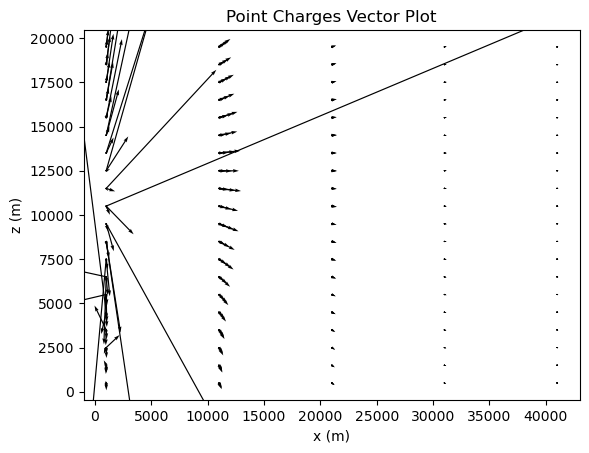

In [33]:
# just to visualize what's going on
skip = 10

plt.figure()

plt.quiver(
    X[::skip],
    Z[::skip],
    Ex_points[0][::skip],
    Ez_points[0][::skip]
)

plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.title('Point Charges Vector Plot')
plt.show()

### Combine

In [34]:
Ex_cyl = Efield[0, :].value
Ey_cyl = Efield[1, :].value
Ez_cyl = Efield[2, :].value

In [35]:
Ex_cyl.shape

(12500,)

In [36]:
Ex_total = -Ex_cyl + Ex_points
Ey_total = -Ey_cyl + Ey_points
Ez_total = -Ez_cyl + Ez_points + E_slab

In [37]:
Ex_total.shape

(1, 12500)

In [38]:
Ex_total_plot = np.reshape(Ex_total[0, :], mesh_shape)
Ey_total_plot = np.reshape(Ey_total[0, :], mesh_shape)
Ez_total_plot = np.reshape(Ez_total[0, :], mesh_shape)

In [39]:
Ez_total_plot.shape

(20, 25, 25)

In [40]:
plotz[:, 0,0]

array([  500.,  1500.,  2500.,  3500.,  4500.,  5500.,  6500.,  7500.,
        8500.,  9500., 10500., 11500., 12500., 13500., 14500., 15500.,
       16500., 17500., 18500., 19500.])

In [41]:
E_total_mag = np.sqrt((Ex_total**2) + (Ey_total**2) + (Ez_total**2))

In [42]:
E_total_mag_plot = np.reshape(E_total_mag[0,:], mesh_shape)

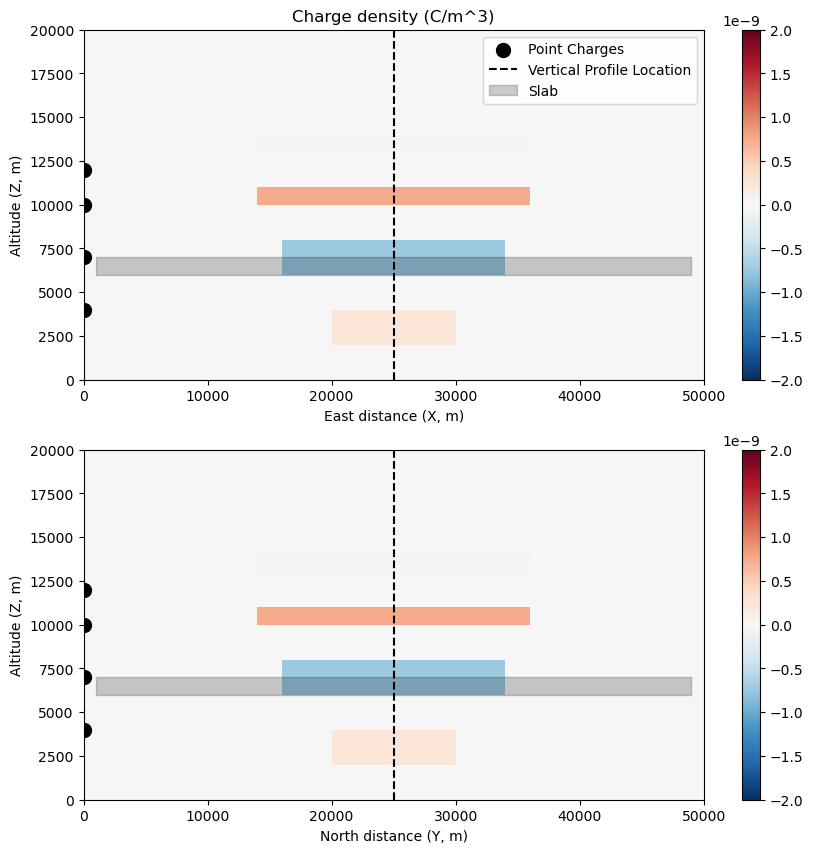

In [43]:
f, axs = plt.subplots(2,1,figsize=(10,10))
ax_rho_EW = axs[0]
ax_rho_NS = axs[1]

rhonorm = matplotlib.colors.Normalize(vmin=-2e-9, vmax=2e-9)

# Select center along Y to plot Z vs. X
rho_plot_EW = ax_rho_EW.pcolormesh(plotx[XZslice], plotz[XZslice], plotrho[XZslice], cmap=red_blue, norm=rhonorm)
ax_rho_EW.set_xlabel("East distance (X, m)")
ax_rho_EW.set_ylabel("Altitude (Z, m)")
ax_rho_EW.set_title("Charge density (C/m^3)")
plt.colorbar(rho_plot_EW, ax=ax_rho_EW)
rho_plot_NS = ax_rho_NS.pcolormesh(ploty[YZslice], plotz[YZslice], plotrho[YZslice], cmap=red_blue, norm=rhonorm)
ax_rho_NS.set_xlabel("North distance (Y, m)")
ax_rho_NS.set_ylabel("Altitude (Z, m)")
ax_rho_EW.scatter([0]*4, z_0, color='k', s=100, label='Point Charges')
ax_rho_NS.scatter([0]*4, z_0, color='k', s=100)
ax_rho_EW.axvline(Xc, color='k', linestyle='--', label='Vertical Profile Location')
ax_rho_NS.axvline(Yc, color='k', linestyle='--', label='Vertical Profile Location')
ax_rho_EW.fill_between(plotx[0,0,:], 7e3, 6e3, label='Slab', alpha=0.2, color='k')
ax_rho_NS.fill_between(ploty[0,:,0], 7e3, 6e3, label='Slab', alpha=0.2, color='k')
plt.colorbar(rho_plot_NS, ax=ax_rho_NS)
ax_rho_EW.legend()

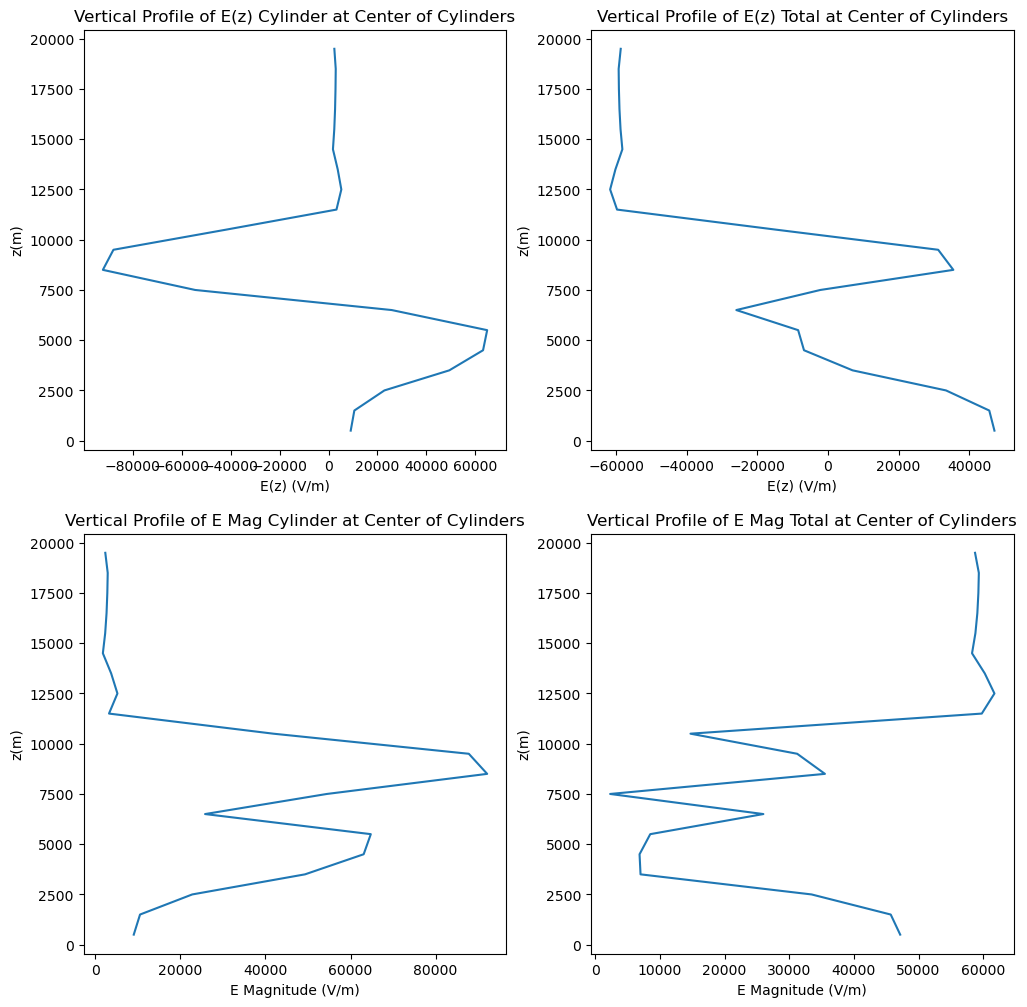

In [44]:
fig, axes = plt.subplots(2,2,figsize=(12,12))
ax0 = axes[0,0]
ax1=axes[0,1]
ax2=axes[1,0]
ax3=axes[1,1]
# Just cylinder z
ax0.plot(Ezplot[:,Xci,Yci], plotz[:, 0,0], label='E')
ax0.set_title(f'Vertical Profile of E(z) Cylinder at Center of Cylinders', wrap=True)
ax0.set_ylabel('z(m)')
ax0.set_xlabel('E(z) (V/m)')

# Total z
ax1.plot(Ez_total_plot[:,Xci,Yci], plotz[:, 0,0], label='E')
ax1.set_title(f'Vertical Profile of E(z) Total at Center of Cylinders', wrap=True)
ax1.set_ylabel('z(m)')
ax1.set_xlabel('E(z) (V/m)')

# Cylinder E mag
ax2.plot(Emagplot[:,Xci,Yci], plotz[:, 0,0], label='E')
ax2.set_title(f'Vertical Profile of E Mag Cylinder at Center of Cylinders', wrap=True)
ax2.set_ylabel('z(m)')
ax2.set_xlabel('E Magnitude (V/m)')

ax3.plot(E_total_mag_plot[:,Xci,Yci], plotz[:, 0,0], label='E')
ax3.set_title(f'Vertical Profile of E Mag Total at Center of Cylinders', wrap=True)
ax3.set_ylabel('z(m)')
ax3.set_xlabel('E Magnitude (V/m)')

plt.show()

### 2. The effect of charge asymmetry

When making balloon-borne measurements of the electric field, it is common to calculate the charge density using only the vertical gradient of the vertical component of the electric field (the 1-D approximation to Gauss's law). This approximation is equivalent to assuming an infinite slab of charge, with no horizontal variability in the electric field.

Repeat question 1, but for a position 5 km offset from the center of the stack of charges.

<span class="ecb">(25)</span>.

In [45]:
X_off = np.argmin(np.abs(plotx-Xc+5e3), axis=-1)[0,0]
Y_off = np.argmin(np.abs(ploty-Yc), axis=-2)[0,0]

In [46]:
X_off

np.int64(9)

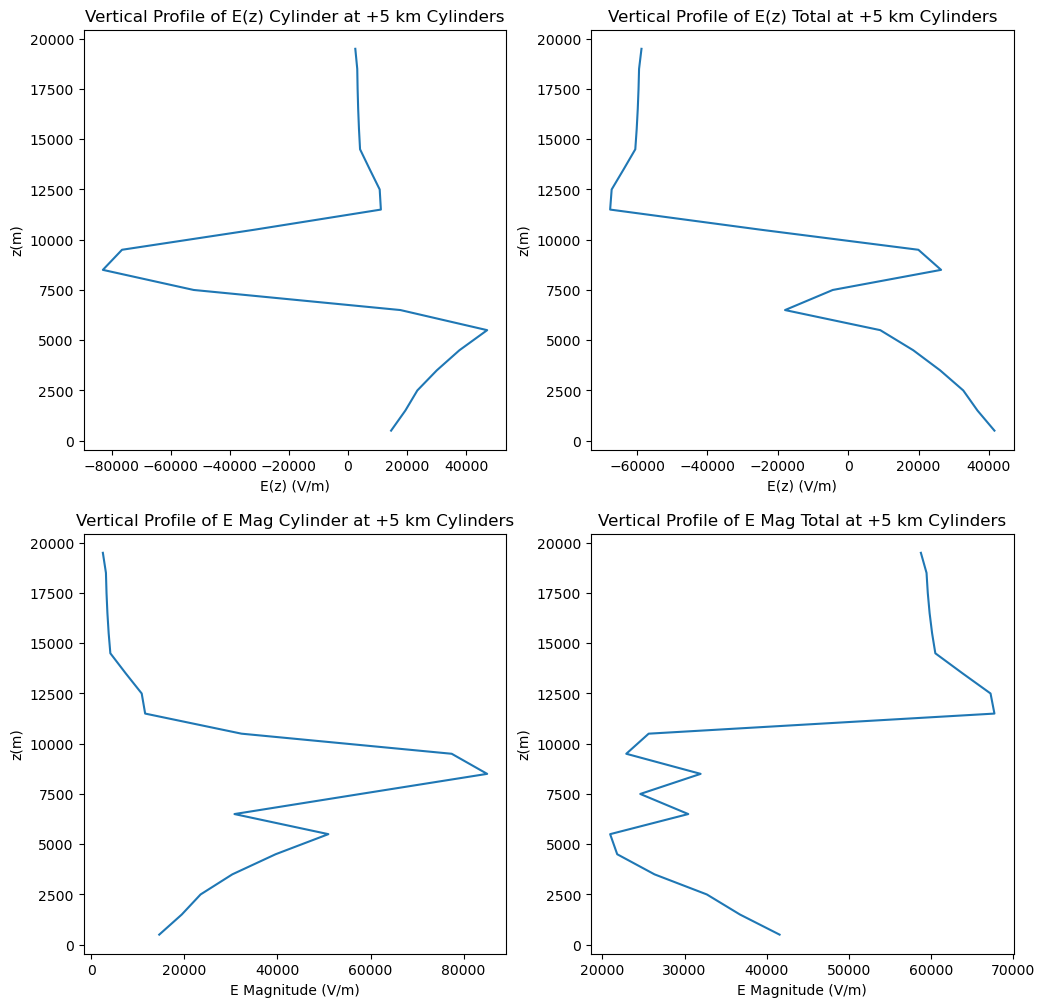

In [47]:
fig, axes = plt.subplots(2,2,figsize=(12,12))
ax0 = axes[0,0]
ax1=axes[0,1]
ax2=axes[1,0]
ax3=axes[1,1]
# Just cylinder z
ax0.plot(Ezplot[:,X_off,Yci], plotz[:, 0,0], label='E')
ax0.set_title(f'Vertical Profile of E(z) Cylinder at +5 km Cylinders', wrap=True)
ax0.set_ylabel('z(m)')
ax0.set_xlabel('E(z) (V/m)')

# Total z
ax1.plot(Ez_total_plot[:,X_off,Yci], plotz[:, 0,0], label='E')
ax1.set_title(f'Vertical Profile of E(z) Total at +5 km Cylinders', wrap=True)
ax1.set_ylabel('z(m)')
ax1.set_xlabel('E(z) (V/m)')

# Cylinder E mag
ax2.plot(Emagplot[:,X_off,Yci], plotz[:, 0,0], label='E')
ax2.set_title(f'Vertical Profile of E Mag Cylinder at +5 km Cylinders', wrap=True)
ax2.set_ylabel('z(m)')
ax2.set_xlabel('E Magnitude (V/m)')

ax3.plot(E_total_mag_plot[:,X_off,Yci], plotz[:, 0,0], label='E')
ax3.set_title(f'Vertical Profile of E Mag Total at +5 km Cylinders', wrap=True)
ax3.set_ylabel('z(m)')
ax3.set_xlabel('E Magnitude (V/m)')

plt.show()

### 3. Electric field at the ground

Electric field measurements at the ground will also vary with the assumed charge structure.

Plot the vertical component of the electric field at the ground as a function of distance from the center of the stack of charges, out to the maximum distance in the FiPy grid. Plot the actual magnitude (top panel) and difference `({slab, point} - FiPy)` (bottom panel).

Discuss the relative errors in the three approaches.

<span class="ecb">(15)</span>.

In [48]:
plotx[0,0,:]

array([ 1000.,  3000.,  5000.,  7000.,  9000., 11000., 13000., 15000.,
       17000., 19000., 21000., 23000., 25000., 27000., 29000., 31000.,
       33000., 35000., 37000., 39000., 41000., 43000., 45000., 47000.,
       49000.])

In [49]:
Xc

25000.0

In [50]:
x_center = np.arange(-Xc, Xc, 2e3)

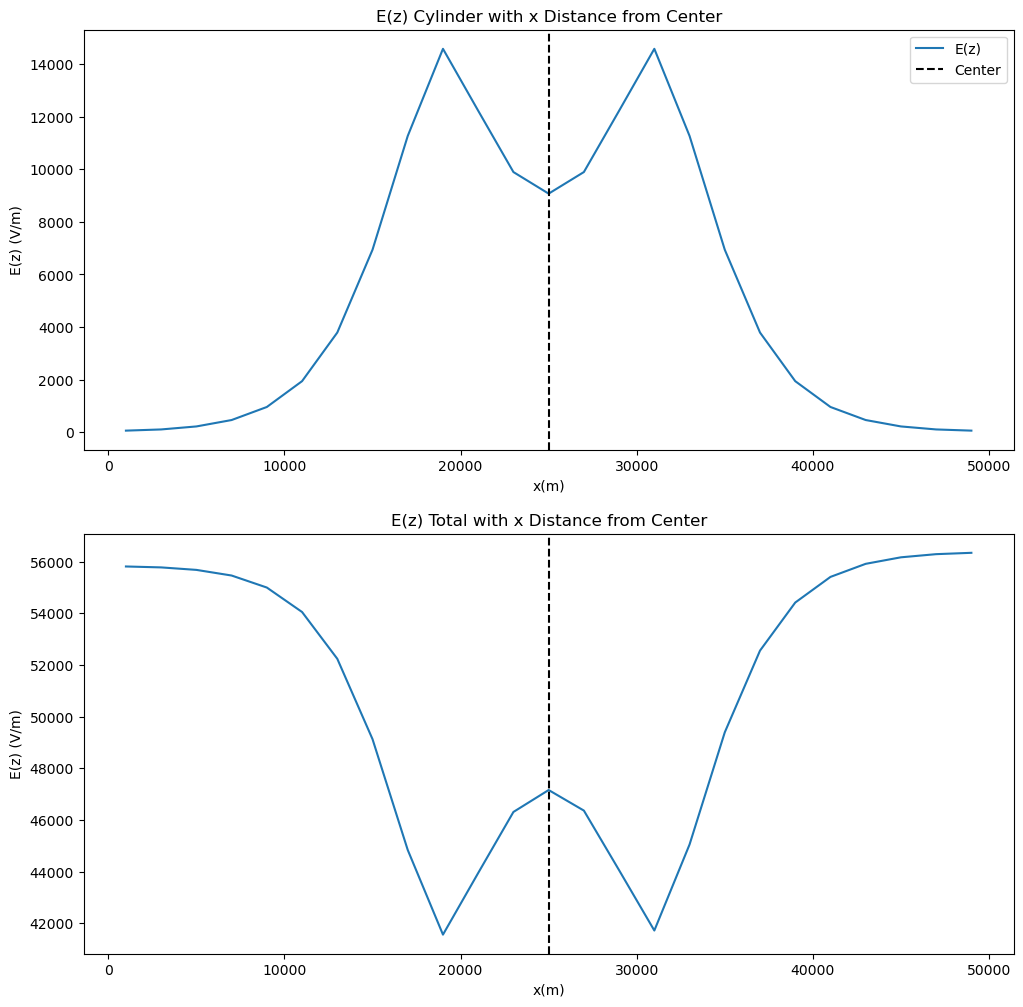

In [51]:
fig, axes = plt.subplots(2,1,figsize=(12,12))
ax0 = axes[0]
ax1= axes[1]
#ax2=axes[1,0]
#ax3=axes[1,1]

# Cylinder E mag
ax0.plot(plotx[0,0,:], Ezplot[0,:,Yci], label='E(z)')
#ax0.plot(x_center, Ezplot[0,:,Yci], label='E(z)')
ax0.set_title(f'E(z) Cylinder with x Distance from Center', wrap=True)
ax0.set_xlabel('x(m)')
ax0.set_ylabel('E(z) (V/m)')
ax0.axvline(Xc, color='k', linestyle='--', label='Center')

ax1.plot(plotx[0,0,:], Ez_total_plot[0,:,Yci], label='E(z)')
ax1.set_title(f'E(z) Total with x Distance from Center', wrap=True)
ax1.set_xlabel('x(m)')
ax1.set_ylabel('E(z) (V/m)')
ax1.axvline(Xc, color='k', linestyle='--', label='Center')
ax0.legend()

plt.show()